# Correlated-Case ($\gamma$) Power Spectrum Correction

Spun off from `DM_benchmark_nico_pypower_1_.ipynb`: **only the correlated case**
(section 3.3 of the derivation notes) and the Setup section.

**Setting.** The corrective potential is $\phi_\mathbf{k} = (\gamma_k/k^2)\Delta_\mathbf{k}$ with
$\gamma_k\in\mathbb{R}$ a real, per-$k$-bin scalar. This is the case most likely to improve
$r(k)$ (cross-correlation coefficient) in addition to $P(k)$, since $\phi$ is built directly
from the density field itself.

Fourier convention (fixed, periodic box):
$$
\Delta_\mathbf{k}=\frac{1}{V}\int_V\Delta(\mathbf{x})e^{-i\mathbf{k}\cdot\mathbf{x}}d^3x,\quad
\Delta(\mathbf{x})=\sum_\mathbf{k}\Delta_\mathbf{k}e^{i\mathbf{k}\cdot\mathbf{x}},\quad
\langle\Delta_\mathbf{k}\Delta_{\mathbf{k}'}^*\rangle=\delta_D(\mathbf{k},\mathbf{k}')\frac{P(k)}{V}.
$$

---

## Equation audit (done before writing this notebook)

**Polynomial (no bispectrum, eq. 104 of the notes):**
$$V\langle|\Delta'_\mathbf{k}|^2\rangle_\Delta = P(k)(1+\gamma_k)^2 - P(k) + P(k) + \gamma_k^2P(k)+2\gamma_kP(k)$$
$$\Rightarrow\quad \gamma_k=-1\pm\sqrt{P_\text{target}(k)/P(k)}$$
`get_roots_gamma` solves $P\gamma^2+2P\gamma+(P-P_\text{target})=0$ via `np.roots`. **No issue.**

**Bispectrum term (eq. 111):** after the June 22 sum-to-integral fix,
$$\text{B.Term}(k)=\frac{k}{2\pi^2}\int_0^{q_\text{max}}q\,\gamma_q\!\left[\int_{-1}^1 y\,B\!\left(k,q,\sqrt{k^2+q^2-2kqy}\right)dy\right]dq,$$
discretized as $M_{ij}=\frac{k_i k_j}{2\pi^2}I_\text{inner}(k_i,k_j)\Delta k_j$.
`build_bispectrum_matrix` (cell 70 of the original) carries the **corrected** factor `1/(2π²)`. **No issue.**

**Bug 1 — `bispectrum_term` (cell 81 of original, root-finding path only):** still used the old
`2*np.power(1./BoxSize,3)` = $2/V$ normalization (pre-June-22), making the Krylov root-finder
converge to the wrong $\gamma_k$. Fixed here: `bispectrum_term` is replaced by a version using
`1./(4*np.pi**3)` (matching cell 64) and kept only for the reconstruction diagnostic; the actual
$\gamma$ solution always uses the linear system (`build_bispectrum_matrix`).

**Bug 2 — displacement in cell 87 (Krylov/root-finding path):** `weights1D = solution["x"]`
should be `weights1D = solution["x"]/k**2`. All other displacement blocks (cells 40/44/73/75) correctly
use `gamma/k**2`. Fixed in `get_phi_and_accel_corr` below, which takes $\gamma_k$ (not
$\gamma_k/k^2$) and divides by $k^2$ internally.

**Manual MAS correction — dropped:** cells 40/73/87 applied a hand-rolled `MAS_factor`
to $\delta_\text{PM}$ before building $\phi$. `CatalogFFTPower` with `resampler='cic'` +
`interlacing=2` already handles MAS deconvolution, so manual application double-compensates.
Only the "without MAS" path from the original (cells 44/75) survives here, renamed to the
single canonical path.


## Imports


In [1]:
import os, time, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
from scipy.interpolate import interp1d
import scipy
import scipy.optimize

import pyfftw
from numba import njit, prange

import psutil
from psutil._common import bytes2human

import readgadget
import bigfile
# pypower
from pypower import CatalogMesh, MeshFFTPower, CatalogFFTPower, PowerSpectrumStatistics, utils, setup_logging
import PolyBin3D as pb

plt.style.use("dark_background")

_trapz = getattr(np, "trapz", None) or np.trapezoid

format_float = lambda z: "%ip%i" % (int(z // 1), int(z % 1 * 10))

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    b = int(b)
    return a + r"$\times 10^{%i}$" % b

print("Numpy version:", np.__version__)
print("Total memory:", bytes2human(psutil.virtual_memory()[0]))
print("Number of CPUs:", os.cpu_count())

figroot = os.path.join("Figures", "Pypower_corrcase")
os.makedirs(figroot, exist_ok=True)
os.makedirs("precomps", exist_ok=True)


Numpy version: 1.23.5
Total memory: 251.6G
Number of CPUs: 128


## Compute resources

Same two-lever split as the Q-case notebook: `pyfftw` calls (phi/gradient FFTs) are
genuinely OpenMP-threaded via `n_threads`; `CatalogFFTPower` (pmesh/pfft) requires
`mpirun` for real multi-rank parallelism.


In [2]:
def detect_compute_resources():
    info = {'cpu_count': os.cpu_count()}
    for var in ("SLURM_CPUS_PER_TASK", "SLURM_NTASKS", "SLURM_JOB_CPUS_PER_NODE"):
        if var in os.environ:
            info[var] = os.environ[var]
    try:
        from mpi4py import MPI
        info['mpi4py_available'] = True
        info['mpi_world_size'] = MPI.COMM_WORLD.Get_size()
    except ImportError:
        info['mpi4py_available'] = False
        info['mpi_world_size'] = 1
    return info

resources = detect_compute_resources()
print(resources)


{'cpu_count': 128, 'SLURM_CPUS_PER_TASK': '32', 'SLURM_NTASKS': '1', 'SLURM_JOB_CPUS_PER_NODE': '32', 'mpi4py_available': True, 'mpi_world_size': 1}


## Shared helper functions (numba + pyfftw, no Pylians)


In [3]:
@njit
def trilinear_interp_numba(data, points, x_coords, y_coords, z_coords):
    nx, ny, nz = data.shape
    num_points = points.shape[0]
    interpolated_values = np.empty(num_points, dtype=data.dtype)
    dx_inv = 1.0 / (x_coords[1] - x_coords[0])
    dy_inv = 1.0 / (y_coords[1] - y_coords[0])
    dz_inv = 1.0 / (z_coords[1] - z_coords[0])
    for i in prange(num_points):
        x_query, y_query, z_query = points[i, :]
        x0_idx = np.searchsorted(x_coords, x_query, side="left") - 1
        y0_idx = np.searchsorted(y_coords, y_query, side="left") - 1
        z0_idx = np.searchsorted(z_coords, z_query, side="left") - 1
        x0_idx, y0_idx, z0_idx = x0_idx % nx, y0_idx % ny, z0_idx % nz
        x1_idx, y1_idx, z1_idx = (x0_idx+1)%nx, (y0_idx+1)%ny, (z0_idx+1)%nz
        x0, y0, z0 = x_coords[x0_idx], y_coords[y0_idx], z_coords[z0_idx]
        xd = (x_query - x0) * dx_inv
        yd = (y_query - y0) * dy_inv
        zd = (z_query - z0) * dz_inv
        c000=data[x0_idx,y0_idx,z0_idx]; c100=data[x1_idx,y0_idx,z0_idx]
        c010=data[x0_idx,y1_idx,z0_idx]; c001=data[x0_idx,y0_idx,z1_idx]
        c110=data[x1_idx,y1_idx,z0_idx]; c101=data[x1_idx,y0_idx,z1_idx]
        c011=data[x0_idx,y1_idx,z1_idx]; c111=data[x1_idx,y1_idx,z1_idx]
        interpolated_values[i] = (
            c000*(1-xd)*(1-yd)*(1-zd) + c100*xd*(1-yd)*(1-zd) +
            c010*(1-xd)*yd*(1-zd)     + c001*(1-xd)*(1-yd)*zd +
            c110*xd*yd*(1-zd)         + c101*xd*(1-yd)*zd +
            c011*(1-xd)*yd*zd         + c111*xd*yd*zd)
    return interpolated_values


@njit
def displace_positions_interp(positions, new_positions, grad_x, grad_y, grad_z,
                                x_c, y_c, z_c, max_length, threshold=None, lr = 1.0):
    nabla_x = trilinear_interp_numba(grad_x, positions, x_c, y_c, z_c) * lr
    nabla_y = trilinear_interp_numba(grad_y, positions, x_c, y_c, z_c) * lr
    nabla_z = trilinear_interp_numba(grad_z, positions, x_c, y_c, z_c) * lr
    if threshold is not None:
        for i in prange(nabla_x.shape[0]):
            mag = np.sqrt(nabla_x[i]**2 + nabla_y[i]**2 + nabla_z[i]**2)
            if mag > threshold:
                scale = threshold / mag
                nabla_x[i] *= scale
                nabla_y[i] *= scale
                nabla_z[i] *= scale
    new_positions[:, 0] = np.mod(positions[:, 0] + nabla_x, max_length)
    new_positions[:, 1] = np.mod(positions[:, 1] + nabla_y, max_length)
    new_positions[:, 2] = np.mod(positions[:, 2] + nabla_z, max_length)
    return new_positions, nabla_x, nabla_y, nabla_z



def fourier_shells_k(res, box_size, fshift=True):
    scale = 2*np.pi*res/box_size
    k_x = np.array(scale*(np.fft.fftshift(np.fft.fftfreq(res)) if fshift
                           else np.fft.fftfreq(res)), dtype='float32')
    kx, ky, kz = np.meshgrid(k_x, k_x, k_x, indexing='ij')
    return k_x, k_x.copy(), k_x.copy(), np.sqrt(kx**2+ky**2+kz**2)


@njit
def fill_fourier_grid(weights_grid, k3D_radius, k_bins, weights1D, zero_above_kmax=True):
    '''
    Interpolate weights1D(k_bins) onto the 3D |k| grid.
    zero_above_kmax (default True): grid points beyond k_bins[-1] get zero weight --
    weights1D was never solved there, so any other value would be fabricated.
    Returns the grid and a diagnostic count of zeroed points.
    '''
    kmax = k_bins[-1]
    n_zeroed = 0
    for ix in prange(k3D_radius.shape[0]):
        for iy in prange(k3D_radius.shape[1]):
            for iz in prange(k3D_radius.shape[2]):
                k_val = k3D_radius[ix, iy, iz]
                if k_val > kmax:
                    if zero_above_kmax:
                        weights_grid[ix, iy, iz] = 0.0
                        n_zeroed += 1
                    else:
                        weights_grid[ix, iy, iz] = weights1D[-1]
                else:
                    weights_grid[ix, iy, iz] = np.interp(k_val, k_bins, weights1D)
    return weights_grid, n_zeroed


## `measure_power_pypower` and caching

Identical to the Q-case notebook: single source of truth for every $P(k)$, `dtype='f4'`,
`interlacing=2` always on, disk-cached by name.


In [4]:
def measure_power_pypower(positions, BoxSize, grid, kedges, resampler='cic',
                           interlacing=2, dtype='f4', ells=(0,), mpiroot=None,
                           remove_shotnoise=True, position_type='pos'):
    result = CatalogFFTPower(data_positions1=positions, boxsize=BoxSize, nmesh=grid,
                              resampler=resampler, edges=kedges, ells=ells,
                              interlacing=interlacing, position_type=position_type,
                              dtype=dtype, mpiroot=mpiroot)
    poles = result.poles
    k, Pk = poles(ell=ells[0], return_k=True, complex=False,
                  remove_shotnoise=remove_shotnoise)
    mask = ~np.isnan(k) & ~np.isnan(Pk)
    return k[mask], Pk[mask]


def cached_measure_power(name, positions, BoxSize, grid, kedges, cache_dir='precomps',
                          recompute=False, **kwargs):
    os.makedirs(cache_dir, exist_ok=True)
    k_path  = os.path.join(cache_dir, f'k_{name}.npy')
    pk_path = os.path.join(cache_dir, f'pk_{name}.npy')
    if not recompute and os.path.exists(k_path) and os.path.exists(pk_path):
        return np.load(k_path), np.load(pk_path)
    start = time.time()
    k, Pk = measure_power_pypower(positions, BoxSize, grid, kedges, **kwargs)
    print(f"  measured P(k) for '{name}' in {time.time()-start:.2f}s")
    np.save(k_path, k); np.save(pk_path, Pk)
    return k, Pk


## Bispectrum computations

In [5]:
def compute_bispectrum_term(gamma_vec, k_vec, ks, bk_monopole):
    '''
    Evaluate B.Term(k) = M @ gamma, using the symmetrized bispectrum matrix.
    The inner integral now correctly covers all q in [0, q_max], including q > k
    (missing in the original loop-based version due to BSpec's k1>=k2 ordering).
    '''
    M = build_bispectrum_matrix(k_vec, ks, bk_monopole)  # already symmetrized

    interp_gamma = interp1d(k_vec, gamma_vec, kind="linear",
                             bounds_error=False, fill_value=(0., gamma_vec[-1]))
    gamma_on_k = interp_gamma(k_vec)
    B_term_full = M @ gamma_on_k  # (n_k,) at all k_vec points

    # Return only at k1 values available in BSpec (consistent with original interface)
    k1_unique = np.unique(ks[0, :])
    def k_to_idx(k_val):
        return int(np.argmin(np.abs(k_vec - k_val)))
    idx = np.array([k_to_idx(k1) for k1 in k1_unique])
    return k1_unique, B_term_full[idx]

def build_bispectrum_matrix(k, ks, bk):
    '''
    Build M s.t. B.Term(k_i) = sum_j M[i,j] * gamma[j].

    I_inner[i,j] = integral_{-1}^{1} y * B(k_i, k_j, k3(y)) dy
    M[i,j] = k_i * k_j / (2*pi^2) * I_inner[i,j] * dk_j

    Key: run BSpec with the SAME kedges as pypower so k-values align exactly
    on the common k-grid. Entries are zero where no valid BSpec triangle exists.
    '''
    n_k = len(k)

    def k_to_idx(k_val):
        return int(np.argmin(np.abs(k - k_val)))

    I_inner = np.zeros((n_k, n_k))
    for k1 in np.unique(ks[0, :]):
        i    = k_to_idx(k1)
        sel  = np.where(ks[0, :] == k1)[0]
        k2_all = ks[1, sel]; k3_all = ks[2, sel]; bk_all = bk[sel]
        for k2 in np.unique(k2_all):
            j      = k_to_idx(k2)
            mask   = (k2_all == k2)
            k3_sub = k3_all[mask]; bk_sub = bk_all[mask]
            y_sub  = (k1**2 + k2**2 - k3_sub**2) / (2*k1*k2)
            order  = np.argsort(y_sub)
            I_inner[i, j] = _trapz(y_sub[order]*bk_sub[order], y_sub[order])

    # BSpec enforces k1 >= k2, so I_inner is lower-triangular.
    # Symmetrize: upper triangle = lower triangle by bispectrum symmetry.
    I_inner += np.tril(I_inner, -1).T   # copy strictly lower triangle to upper

    dk = np.empty(n_k)
    dk[1:-1] = (k[2:] - k[:-2]) / 2
    dk[0]    = (k[1] - k[0]) / 2
    dk[-1]   = (k[-1] - k[-2]) / 2

    M = (1/(2*np.pi**2)) * k[:, None] * k[None, :] * I_inner * dk[None, :]
    return M

In [6]:
def compute_density_slice_2d(positions, BoxSize, grid,
                               x_min, x_max, y_min, y_max, z_min, z_max):
    '''
    2D CIC projected density (1+delta) on the XY plane, averaged over
    z in [z_min, z_max]. No Pylians, no pypower.
    Returns array of shape (nx, ny) in 1+delta units.
    '''
    cell = BoxSize / grid
    nx = max(1, int(round((x_max - x_min) / cell)))
    ny = max(1, int(round((y_max - y_min) / cell)))

    mask = ((positions[:, 0] >= x_min) & (positions[:, 0] < x_max) &
            (positions[:, 1] >= y_min) & (positions[:, 1] < y_max) &
            (positions[:, 2] >= z_min) & (positions[:, 2] < z_max))
    pos = positions[mask]

    xc = (pos[:, 0] - x_min) / cell
    yc = (pos[:, 1] - y_min) / cell
    i0 = np.floor(xc).astype(int) % nx
    j0 = np.floor(yc).astype(int) % ny
    dx = xc - np.floor(xc)
    dy = yc - np.floor(yc)

    rho = np.zeros((nx, ny), dtype='f4')
    for di in (0, 1):
        for dj in (0, 1):
            wx = dx if di else 1.0 - dx
            wy = dy if dj else 1.0 - dy
            np.add.at(rho, ((i0 + di) % nx, (j0 + dj) % ny), wx * wy)

    nbar = rho.mean()
    return rho / nbar if nbar > 0 else rho + 1.0


def plot_density_slices(pos_list, labels, BoxSize, grid,
                         x_min, x_max, y_min, y_max, z_min, z_max,
                         scale='log', colmap='hot', dmin=0.1, dmax=100,
                         smooth_sigma=None, figroot=None,
                         fname='dfield_slices.pdf'):
    '''
    One-row, N-column density-field slice plot with a single shared colorbar.
    No Pylians. Default: compare initial PM to corrected positions.

    Parameters
    ----------
    pos_list     : list of (N,3) float32 arrays, one per panel
    labels       : list of str panel titles
    BoxSize,grid : box size and mesh resolution (same as power-spectrum calls)
    x/y/z_min/max: spatial extent; z range sets the slab depth averaged over
    scale        : 'log' or 'linear'
    dmin, dmax   : clipping limits on 1+delta
    smooth_sigma : optional Gaussian smoothing in grid cells (None = off)
    figroot      : directory to save PDF; None = don't save
    '''
    from scipy.ndimage import gaussian_filter

    n = len(pos_list)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5.5),
                              sharey=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    fields = []
    for pos in pos_list:
        d = compute_density_slice_2d(pos, BoxSize, grid,
                                      x_min, x_max, y_min, y_max, z_min, z_max)
        if smooth_sigma is not None:
            d = gaussian_filter(d, sigma=smooth_sigma)
        fields.append(np.clip(d, dmin, dmax))

    vmin = min(f.min() for f in fields)
    vmax = max(f.max() for f in fields)
    norm = LogNorm(vmin=vmin, vmax=vmax) if scale == 'log' else \
           plt.Normalize(vmin=vmin, vmax=vmax)

    extent = [x_min, x_max, y_min, y_max]
    im = None
    for ax, field, label in zip(axes, fields, labels):
        im = ax.imshow(field.T, origin='lower', extent=extent,
                        cmap=colmap, norm=norm,
                        interpolation='sinc', aspect='equal')
        ax.set_title(label, fontsize=14)
        ax.set_xlabel(r'$x\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
    axes[0].set_ylabel(r'$y\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)

    cbar = fig.colorbar(im, ax=axes, fraction=0.05, pad=0.02, aspect=30)
    cbar.set_label(r'$1+\delta$', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    fig.suptitle(r'$z \in [%.1f,\,%.1f]\ h^{-1}\mathrm{Mpc}$' % (z_min, z_max),
                  fontsize=16)

    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, fname), bbox_inches='tight')
    return fig, axes

# 1) Setup and load data


In [7]:
params = ["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
cosmology = {"sigma_8": 0.834, "n_s": 0.9624, "h": 0.671,
             "Omega_b": 0.049, "Omega_m": 0.3175}


In [8]:
grid    = 256
BoxSize = 1000.0   # overwritten from header below
MAS     = 'CIC'
redshift      = 0.5
a             = 1 / (1 + redshift)
z_str         = format_float(redshift)
seed          = 1
interlacing_order = 2
appstr        = "FastPM"

# SNAPSHOT LOCATIONS -- edit these for your run
nbody= "/work/hdd/bdne/nchartier/quijote_lh/%i/snap_003"%(seed)
app = "/work/hdd/bdne/maho3/cmass-ili/quijotelike_for_nicolas/fastpm/L1000-N128/%i/fastpm_B2_0.6667"%seed
ptype = [1]  # [1] CDM, [2] neutrinos, [1, 2] CDM+neutrinos

basedir = "/u/nchartier/PkCorr/Figures"
os.makedirs(os.path.join(basedir, appstr), exist_ok=True)


In [9]:
header  = readgadget.header(nbody)
BoxSize = header.boxsize / 1e3
print("BoxSize = %.1f Mpc/h" % BoxSize)
pos_nb  = readgadget.read_block(nbody, "POS ", ptype) / 1e3

infile = bigfile.File(app)
pos_pm = infile['1/Position'][:]  # comoving positions [Mpc/h]
print("pos_pm:", pos_pm.shape, "  pos_nb:", pos_nb.shape)


BoxSize = 1000.0 Mpc/h
pos_pm: (56623104, 3)   pos_nb: (134217728, 3)


In [10]:
kNyquist = np.pi * grid / BoxSize
kFund    = 2 * np.pi / BoxSize
num_bins = 50
kedges   = np.linspace(kFund, kNyquist, num_bins)[:-1]
ells     = (0,)

# k grid actually used for solving (truncated at kNyquist)
kN = kNyquist


In [13]:
recompute = True

suffix = "fastpm_%i_bins_%i_grid"%(num_bins, grid)
start = time.time()
k_pm, Pk_pm = cached_measure_power('pm_%s'%(suffix), pos_pm, BoxSize, grid, kedges, ells=ells, recompute=recompute)
k_nb, Pk_nb = cached_measure_power('nb_%s'%suffix, pos_nb, BoxSize, grid, kedges, ells=ells, recompute=recompute)
# raw (shot-noise-not-removed) versions, needed for the cross-correlation coefficient r(k)
# (pypower subtracts shot noise from auto-spectra by default but never from cross-spectra,
# so comparing a shot-noise-subtracted auto against a cross can give r(k) > 1 -- see note below), recompute=recompute
k_pm_raw, Pk_pm_raw = cached_measure_power('pm_%s_raw'%suffix, pos_pm, BoxSize, grid, kedges, ells=ells, remove_shotnoise=False, recompute=recompute)
k_nb_raw, Pk_nb_raw = cached_measure_power('nb_%s_raw'%suffix, pos_nb, BoxSize, grid, kedges, ells=ells, remove_shotnoise=False, recompute=recompute)

result_X = CatalogFFTPower(data_positions1=pos_nb, data_positions2=pos_pm, boxsize=BoxSize, nmesh=grid,
                            resampler=MAS.lower(), edges=kedges, ells=ells,
                            interlacing=interlacing_order, position_type='pos', dtype='f4')
k_X, Pk_X = result_X.poles(ell=ells[0], return_k=True, complex=False)
mask_X = ~np.isnan(k_X) & ~np.isnan(Pk_X)
k_X, Pk_X = k_X[mask_X], Pk_X[mask_X]
print("%.2f seconds for the pm/nb/cross P(k) measurements" % (time.time() - start))

  measured P(k) for 'pm_fastpm_50_bins_256_grid' in 36.43s
  measured P(k) for 'nb_fastpm_50_bins_256_grid' in 92.65s
  measured P(k) for 'pm_fastpm_50_bins_256_grid_raw' in 36.58s
  measured P(k) for 'nb_fastpm_50_bins_256_grid_raw' in 90.31s
384.09 seconds for the pm/nb/cross P(k) measurements


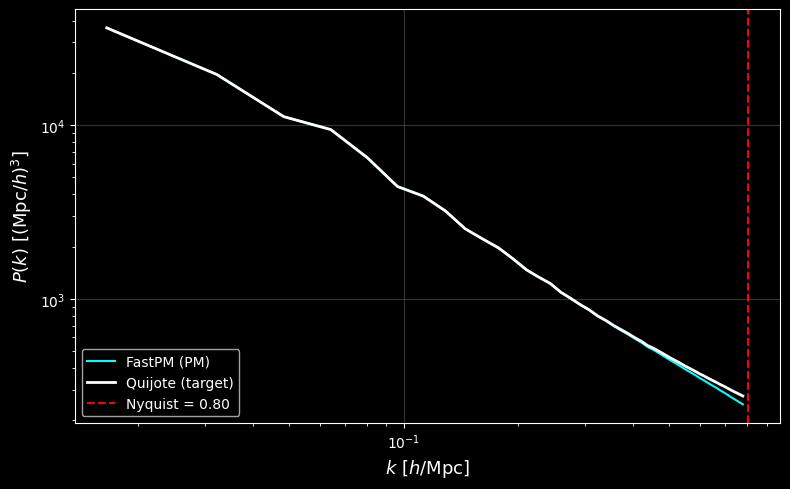

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_pm, Pk_pm, label="FastPM (PM)", color="cyan")
ax.plot(k_nb, Pk_nb, label="Quijote (target)", color="white", lw=2)
ax.axvline(kNyquist, color='r', ls='--', label='Nyquist = %.2f' % kNyquist)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax.legend(); ax.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "initial_power_spectra.pdf"), bbox_inches="tight")


# 2) Correlated case: $\phi_\mathbf{k} = (\gamma_k/k^2)\Delta_\mathbf{k}$


## 2-1) Polynomial (no bispectrum)

Dropping bispectrum and trispectrum terms (eq. 104 of the notes):
$$V\langle|\Delta'_\mathbf{k}|^2\rangle_\Delta = P(k) + \gamma_k^2P(k) + 2\gamma_k P(k) = P_\text{target}(k)$$
$$\Rightarrow\quad \gamma_k = -1 \pm \sqrt{P_\text{target}(k)/P(k)}$$

The "positive" root ($+$) is physically motivated when $P_\text{target}>P$ (need to add power),
and the "negative" root when $P_\text{target}<P$. Both are computed; we default to the positive
root but expose the choice.


In [15]:
def get_roots_gamma(k, Pk, Pk_target):
    '''
    Per-k quadratic: P*gamma^2 + 2P*gamma + (P - P_target) = 0
    Returns roots (n_k, 2) and coeffs (n_k, 3).
    '''
    a = Pk; b = 2*Pk; c = Pk - Pk_target
    coeffs = np.column_stack([a, b, c])
    roots  = np.array([np.roots(coeffs[i]) for i in range(len(k))])
    return roots, coeffs


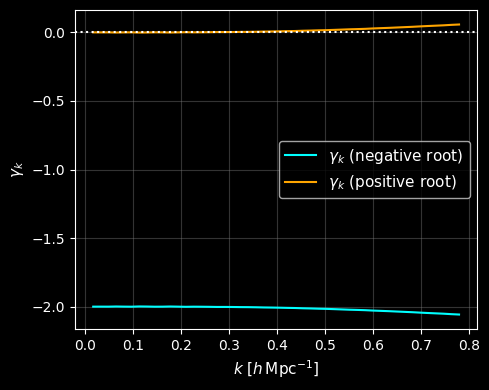

In [16]:
# Restrict to k <= kNyquist
inds = k_nb <= kN
k       = k_nb[inds]
Pk_pm_k = Pk_pm[inds]
Pk_nb_k = Pk_nb[inds]

roots, coeffs = get_roots_gamma(k, Pk_pm_k, Pk_nb_k)

# Positive root (use when P_target > P_PM mostly)
gamma_k = roots[:, 1].real

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(k, roots[:, 0].real, label=r"$\gamma_k$ (negative root)", color="cyan")
ax.plot(k, roots[:, 1].real, label=r"$\gamma_k$ (positive root)", color="orange")
ax.axhline(0, ls="dotted", color="white")
ax.legend(fontsize=11)
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=11)
ax.set_ylabel(r"$\gamma_k$", fontsize=11)
ax.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gammak_roots.pdf"), bbox_inches="tight")


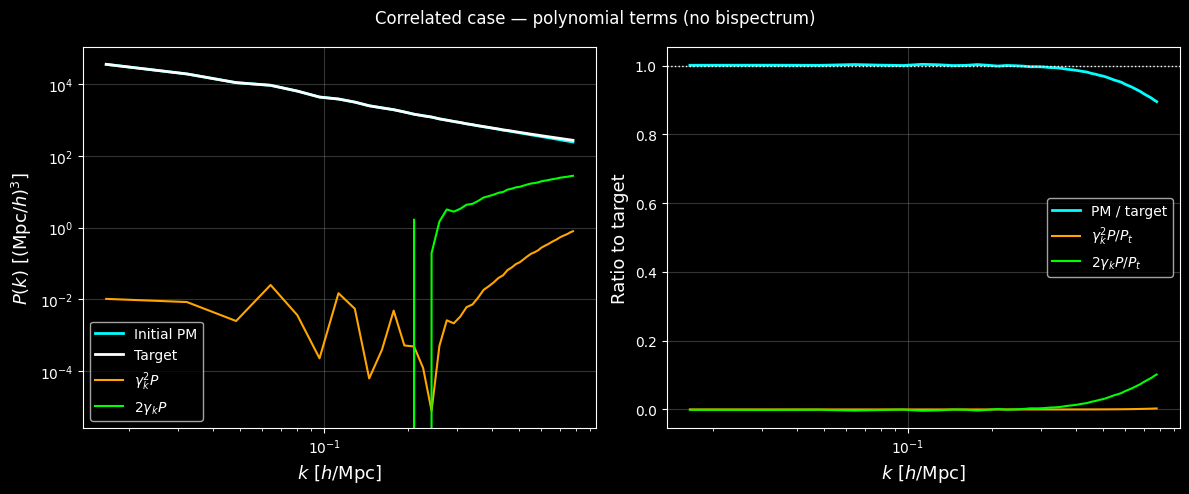

In [17]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k, Pk_pm_k,                         label="Initial PM",       color="cyan",   lw=2)
ax1.plot(k, Pk_nb_k,                          label="Target",           color="white",  lw=2)
ax1.plot(k, coeffs[:, 0]*gamma_k**2,          label=r"$\gamma_k^2 P$", color="orange", lw=1.5)
ax1.plot(k, coeffs[:, 1]*gamma_k,             label=r"$2\gamma_k P$",  color="lime",   lw=1.5)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

ax2.plot(k, Pk_pm_k/Pk_nb_k,                            label="PM / target",          color="cyan",   lw=2)
ax2.plot(k, coeffs[:, 0]*gamma_k**2/Pk_nb_k,            label=r"$\gamma_k^2P/P_t$",  color="orange", lw=1.5)
ax2.plot(k, coeffs[:, 1]*gamma_k/Pk_nb_k,               label=r"$2\gamma_k P/P_t$",  color="lime",   lw=1.5)
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax2.set_ylabel("Ratio to target", fontsize=13)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)

plt.suptitle("Correlated case — polynomial terms (no bispectrum)")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "correlated_terms_noBk.pdf"), bbox_inches="tight")


## 2-2) Generate $\phi(\mathbf{x})$ and displace particles (polynomial $\gamma_k$)

$\phi_\mathbf{k} = (\gamma_k/k^2)\,\Delta_\mathbf{k}$, so we need the Fourier-space density
field $\Delta_\mathbf{k}$ from the PM snapshot. We then build $\nabla\phi$ via `ifft(ik\phi_k)`.

**No manual MAS correction is applied** to $\Delta_k$ — `CatalogFFTPower` handles that
internally for the $P(k)$ measurements, and applying it again here on the density field before
building $\phi$ would double-compensate the window. See the equation audit in the intro.


In [23]:
def MAS_correction(x, MAS_index):
    '''
    MAS deconvolution factor: (x/sin(x))^MAS_index.
    For CIC (MAS_index=2) with x = pi*f where f = fftfreq in [-0.5, 0.5):
        x/sin(x) = 1/sinc(f)  (unnormalized sinc)
    i.e. multiplying delta_k by this factor divides by the CIC window, recovering
    the unwindowed field. Matches pypower's _get_compensation_window 'shotnoise=False'
    path (eq. 18, Jing 2005): sinc(0.5/pi * kc)^p where kc = k * cellsize.
    '''
    x = np.asarray(x, dtype=float)
    out = np.ones_like(x)
    nonzero = x != 0.0
    out[nonzero] = (x[nonzero] / np.sin(x[nonzero])) ** MAS_index
    return out


def get_delta_fourier(delta_pm, grid, BoxSize, n_threads=1,
                       apply_mas_deconv=True, MAS_index=2):
    '''
    Forward pyfftw of the real-space CIC density field -> fftshift-d Fourier field.

    apply_mas_deconv (default True): divide delta_k by the CIC window function
    in Fourier space, recovering the unwindowed density field.

    Why this matters -- confirmed from pypower source (mesh.py):

      CatalogMesh.to_mesh() has `compensate=False` by default. Compensation
      (MAS deconvolution) is only applied when compensate=True is passed, via
      _compensate() which divides the Fourier mesh by the CIC window. CatalogFFTPower
      itself never calls to_mesh() -- it creates CatalogMesh objects and delegates to
      MeshFFTPower (its parent class), which is where to_mesh(compensate=True) is
      actually called (confirmed from CatalogFFTPower source: the only nthreads usage
      is for the direct pair-counting engine, not the FFT path). But any raw mesh object (from CatalogMesh.to_mesh()
      or from MASL.MA + pyfftw as done here) does NOT have the window removed unless
      you explicitly request it.

      The pypower-native equivalent would be:
          CatalogMesh(pos_pm, nmesh=grid, boxsize=BoxSize, resampler='cic',
                      interlacing=2, position_type='pos').to_mesh(compensate=True)
      but that returns a pmesh.pm.ComplexField (slab-distributed), not a numpy array,
      requiring extra pmesh boilerplate to extract. MASL.MA + pyfftw + manual
      MAS_correction is mathematically equivalent and gives a plain numpy array.

    Small subtlety: CatalogFFTPower/MeshFFTPower combines two interlaced (phase-shifted) CIC meshes
    before compensating. MASL.MA is plain CIC without interlacing. The compensation
    formula used here (sinc^p, eq. 18 Jing 2005 = pypower's shotnoise=False path)
    is technically designed for the interlaced case; for a plain CIC field without
    interlacing, eq. 19 would be more consistent. The difference is small at k << kNyq.

    Set apply_mas_deconv=False to reproduce the original "without MAS" path
    (cells 44/75 of DM_benchmark_nico_pypower_1_.ipynb).
    '''
    prec_in = "complex64"
    a_in  = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
    a_out = pyfftw.empty_aligned((grid, grid, grid), dtype='complex64')
    plan  = pyfftw.FFTW(a_in, a_out, axes=(0, 1, 2), flags=('FFTW_ESTIMATE',),
                         direction='FFTW_FORWARD', threads=n_threads)
    a_in[:] = delta_pm.astype(prec_in)
    delta_k_shift = np.fft.fftshift(plan(a_in, a_out), axes=(0, 1, 2))

    if apply_mas_deconv:
        # f in [-0.5, 0.5), x = pi*f; MAS_correction(x,2) = 1/sinc(f)^2 = 1/W_CIC
        freq = np.fft.fftshift(np.fft.fftfreq(grid))
        fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')
        MAS_factor = (MAS_correction(np.pi * fx, MAS_index) *
                      MAS_correction(np.pi * fy, MAS_index) *
                      MAS_correction(np.pi * fz, MAS_index))
        delta_k_shift = delta_k_shift * MAS_factor.astype('complex64')

    return delta_k_shift

def get_phi_and_accel_corr(gamma1D, k, delta_k_shift, grid, BoxSize, n_threads=1,
                             zero_above_kmax=True, verbose=True):
    '''
    Build phi_k = (gamma_k/k^2) * delta_k and return its three real-space gradients.

    Parameters
    ----------
    gamma1D      : (n_k,) array -- solved gamma_k values (NOT pre-divided by k^2;
                   division is done internally to prevent the bug in cell 87 of the
                   original notebook where solution["x"] was passed without /k^2)
    k            : (n_k,) array -- k-bin centers matching gamma1D
    delta_k_shift: fftshift-d forward-FFT of the CIC density field (from get_delta_fourier)
    zero_above_kmax : if True (default), grid points with |k| > k[-1] get zero weight --
                   gamma was never solved beyond there, so any other value is fabricated.
                   Prints a diagnostic count of how many grid points are affected.
    '''
    kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift=True)

    # weights = gamma_k / k^2, safeguarded at k=0
    weights1D = np.where(k > 0, gamma1D / k**2, 0.0).astype('float32')

    weights_grid = np.empty(delta_k_shift.shape, dtype='float32')
    weights_grid, n_zeroed = fill_fourier_grid(
        weights_grid, k_radius, k, weights1D,
        zero_above_kmax=zero_above_kmax)

    if verbose:
        frac = n_zeroed / k_radius.size
        print(f"  fill_fourier_grid: zero_above_kmax={zero_above_kmax} -> "
              f"{n_zeroed}/{k_radius.size} points ({frac:.1%}) beyond "
              f"k_max={k[-1]:.4f} h/Mpc zeroed.")

    phi_k = weights_grid * delta_k_shift

    scale = 2 * np.pi * grid / BoxSize
    kv = np.array(np.fft.fftshift(np.fft.fftfreq(grid)) * scale, dtype="float32")

    accel = []
    prec_out = "complex64"
    for axis_vec in (kv[:, None, None], kv[None, :, None], kv[None, None, :]):
        arr_in  = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
        arr_out = pyfftw.empty_aligned((grid, grid, grid), dtype="complex64")
        plan = pyfftw.FFTW(arr_in, arr_out, axes=(0, 1, 2), flags=('FFTW_ESTIMATE',),
                            direction='FFTW_BACKWARD', threads=n_threads)
        arr_in[:] = (1.0j * axis_vec * phi_k).astype(prec_out)
        accel.append(plan(np.fft.ifftshift(arr_in), arr_out).real)

    return phi_k, accel, n_zeroed

In [24]:
# Build delta_pm field (needed to construct phi_k = gamma_k/k^2 * delta_k)

# Replace with:
mesh = CatalogMesh(data_positions=pos_pm, boxsize=BoxSize, nmesh=grid,
                   resampler='cic', interlacing=0, position_type='pos', dtype='f4')
delta_pm = np.array(mesh.to_mesh(compensate=False))
delta_pm = (delta_pm / delta_pm.mean() - 1.0).astype('float32')

n_threads = resources['cpu_count'] or 1
delta_k_shift = get_delta_fourier(delta_pm, grid, BoxSize, n_threads=n_threads,
                                   apply_mas_deconv=True)


In [25]:
cell = BoxSize / grid
length_grid = np.arange(0., BoxSize, cell)

In [26]:
# Displace particles with polynomial gamma_k (no bispectrum)
phi_k_poly, accel_poly, _ = get_phi_and_accel_corr(
    gamma_k, k, delta_k_shift, grid, BoxSize, n_threads=n_threads,
    zero_above_kmax=True, verbose=True)

cell = BoxSize / grid
length_grid = np.arange(0., BoxSize, cell)
pos_corr_poly = np.empty(pos_pm.shape, dtype="float32")
pos_corr_poly, *_ = displace_positions_interp(
    pos_pm.astype("float32"), pos_corr_poly,
    accel_poly[0].astype("float32"),
    accel_poly[1].astype("float32"),
    accel_poly[2].astype("float32"),
    length_grid, length_grid, length_grid, BoxSize, threshold=None, lr = 0.5) # threshold = BoxSize/grid before


  fill_fourier_grid: zero_above_kmax=True -> 8766155/16777216 points (52.3%) beyond k_max=0.7799 h/Mpc zeroed.


Mean |disp| = 0.07942 Mpc/h  (cell = 3.906 Mpc/h)
  measured P(k) for 'fastpm_corr_poly_fastpm_50_bins_256_grid' in 41.49s


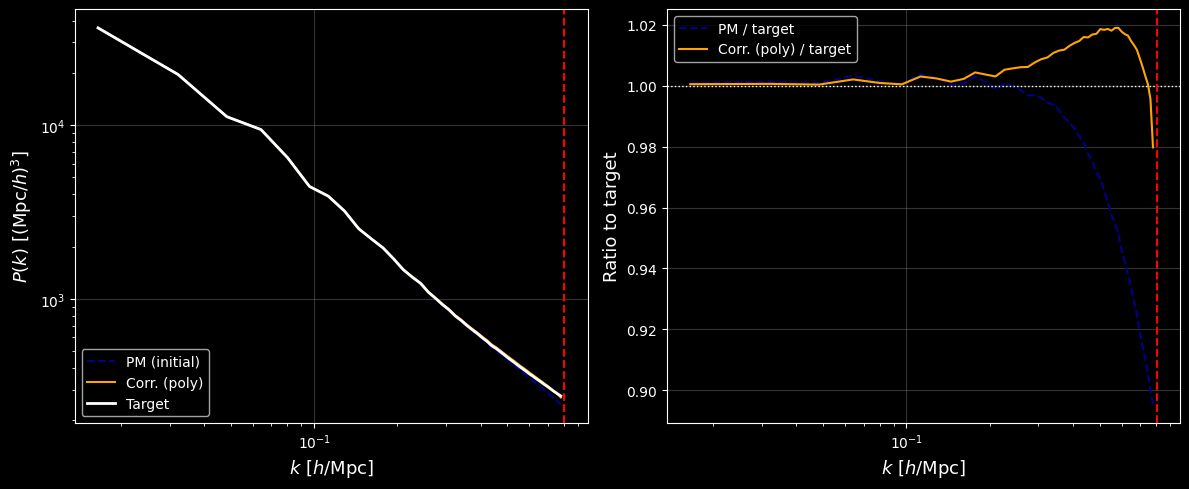

In [27]:
mean_disp = np.mean(np.linalg.norm(pos_corr_poly - pos_pm.astype('float32'), axis=1))
print("Mean |disp| = %.4g Mpc/h  (cell = %.4g Mpc/h)" % (mean_disp, BoxSize/grid))

k_poly, Pk_poly = cached_measure_power('fastpm_corr_poly_%s'%suffix, pos_corr_poly, BoxSize, grid, kedges, ells=ells, recompute=True)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes
ax1.plot(k_pm,    Pk_pm,    label="PM (initial)",  color="darkblue", ls="--")
ax1.plot(k_poly,  Pk_poly,  label="Corr. (poly)",  color="orange")
ax1.plot(k_nb,    Pk_nb,    label="Target",         color="white", lw=2)
ax1.axvline(kNyquist, color='r', ls='--')
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

ax2.plot(k_pm, Pk_pm/np.interp(k_pm, k_nb, Pk_nb),    label="PM / target",  color="darkblue", ls="--")
ax2.plot(k_poly, Pk_poly/np.interp(k_poly, k_nb, Pk_nb), label="Corr. (poly) / target", color="orange")
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.axvline(kNyquist, color='r', ls='--')
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax2.set_ylabel("Ratio to target", fontsize=13)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Pk_corr_poly.pdf"), bbox_inches="tight")

## 2-3) Bispectrum computation (PolyBin3D)

We use the same `kedges` as pypower so that BSpec's $k_1,k_2$ bin centers land on the
same grid as our $P(k)$ bins — the key to building `build_bispectrum_matrix` without
any interpolation between the two grids.


In [28]:
start = time.time()
base = pb.PolyBin3D(
    [BoxSize, BoxSize, BoxSize],
    [grid, grid, grid],
    boxcenter=[0, 0, 0],
    pixel_window='cic',
    backend='fftw',
    nthreads=n_threads,
    sightline='global')
print("PolyBin3D base init: %.1f s" % (time.time()-start))
print("k_fund = %.4f,  mean dk = %.4f" % (kFund, np.mean(np.diff(k_pm))))

down_factor = 1   # increase to speed up bispectrum (at the cost of k-resolution)
k_down = kedges[::down_factor]

bspec = pb.BSpec(base, k_down, lmax=0)
ks = bspec.get_ks()
k1_vals = np.unique(ks[0, :])
print("BSpec: %d valid triplets, %d unique k1 values" % (ks.shape[1], len(k1_vals)))



# Dimensions: [1.00e+03, 1.00e+03, 1.00e+03] Mpc/h
# Center: [0.00e+00, 0.00e+00, 0.00e+00] Mpc/h
# Line-of-sight: global
# Cartesian grid: [256, 256, 256]
# Fundamental frequency: [0.0063, 0.0063, 0.0063] h/Mpc
# Nyquist frequency: [0.804, 0.804, 0.804] h/Mpc
# Pixel window: cic
# Using FFTW backend
PolyBin3D base init: 4.4 s
k_fund = 0.0063,  mean dk = 0.0162

Binning: 48 bins in [0.006, 0.788] h/Mpc
l-max: 0
N_bins: 10100
Mask: constant
BSpec: 10100 valid triplets, 48 unique k1 values


In [29]:
recompbisp = True
bk_path = os.path.join("precomps", "bk_pm_%s.npy" % suffix) ;print(bk_path)
ks_path = os.path.join("precomps", "bk_bins_%s.npy" % suffix) ; print(ks_path)
#bk_path = os.path.join("precomps", "bk_pm_bins%i_grid%i.npy" % (num_bins, grid))
#ks_path = os.path.join("precomps", "bk_bins_bins%i_grid%i.npy" % (num_bins, grid))

if os.path.exists(bk_path) and not recompbisp:
    print("Loading bispectrum from cache")
    bk_uncorr = np.load(bk_path)
    ks        = np.load(ks_path)
else:
    start = time.time()
    result_bk = bspec.Bk_ideal(delta_pm, discreteness_correction=False)
    bk_uncorr = result_bk["b0"]
    ks        = bspec.get_ks()
    np.save(bk_path, bk_uncorr)
    np.save(ks_path, ks)
    print("Bispectrum computed in %.1f s" % (time.time()-start))

print("bk shape:", bk_uncorr.shape, "  ks shape:", ks.shape)
k1_vals = np.unique(ks[0, :])


precomps/bk_pm_fastpm_50_bins_256_grid.npy
precomps/bk_bins_fastpm_50_bins_256_grid.npy
Computing degeneracy factor
Computing ideal Fisher matrix
Bispectrum computed in 183.5 s
bk shape: (10100,)   ks shape: (3, 10100)


## 2-4) Bispectrum term contribution

Using $\gamma_k$ from the polynomial (section 2-1) as a plug-in to visualize the
bispectrum term's magnitude — **not** yet solving for $\gamma$ from the full system.

The corrected sum-to-integral factor $1/(4\pi^3)$ (i.e. $2/(2\pi)^3$, from the
June 22 fix to cell 64 of the original) is used here. Note this replaces the
`bispectrum_term` in cell 81 of the original which still used the wrong $2/V$.


Bispectrum term computed in 0.03 s


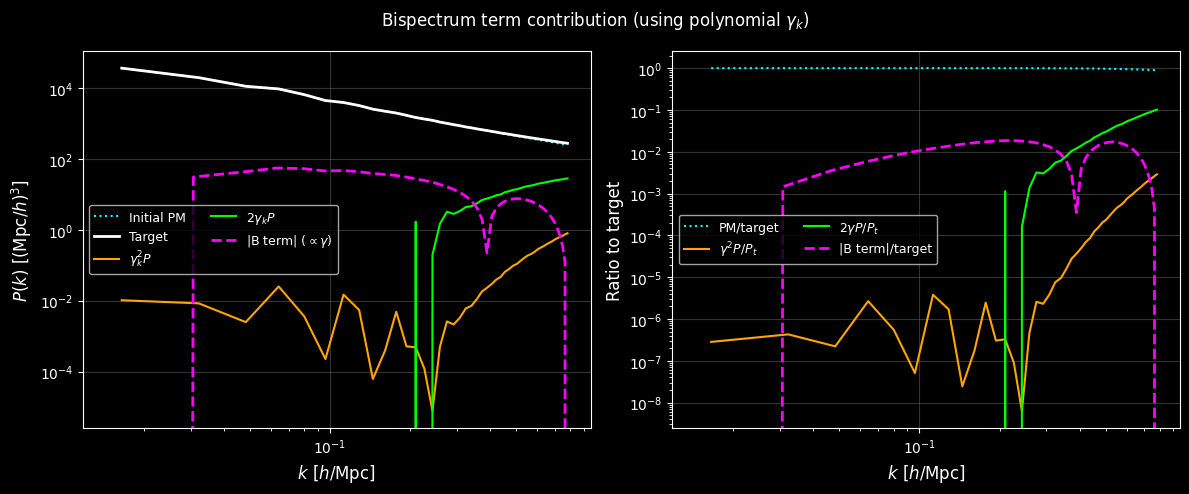

In [30]:
start = time.time()
k1v, B_term_poly = compute_bispectrum_term(gamma_k, k, ks, bk_uncorr)
print("Bispectrum term computed in %.2f s" % (time.time()-start))

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k,   Pk_pm_k,              label="Initial PM",          color="cyan",     ls="dotted", lw=1.5)
ax1.plot(k,   Pk_nb_k,              label="Target",              color="white",    lw=2)
ax1.plot(k,   coeffs[:,0]*gamma_k**2, label=r"$\gamma_k^2P$",    color="orange",   lw=1.5)
ax1.plot(k,   coeffs[:,1]*gamma_k,    label=r"$2\gamma_k P$",    color="lime",     lw=1.5)
ax1.plot(k1v, np.abs(B_term_poly),  label=r"|B term| ($\propto\gamma$)", color="magenta", ls="--", lw=2)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=12)
ax1.legend(fontsize=9, ncols=2); ax1.grid(color="grey", alpha=0.4)

Pk_nb_i = np.interp(k1v, k, Pk_nb_k)
ax2.plot(k,   Pk_pm_k/Pk_nb_k,              color="cyan",   ls="dotted", lw=1.5, label="PM/target")
ax2.plot(k,   coeffs[:,0]*gamma_k**2/Pk_nb_k, color="orange", lw=1.5, label=r"$\gamma^2P/P_t$")
ax2.plot(k,   coeffs[:,1]*gamma_k/Pk_nb_k,    color="lime",   lw=1.5, label=r"$2\gamma P/P_t$")
ax2.plot(k1v, np.abs(B_term_poly)/Pk_nb_i,  color="magenta", ls="--", lw=2, label="|B term|/target")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
ax2.set_ylabel("Ratio to target", fontsize=12)
ax2.legend(fontsize=9, ncols=2); ax2.grid(color="grey", alpha=0.4)

plt.suptitle("Bispectrum term contribution (using polynomial $\\gamma_k$)")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Bk_term_contribution.pdf"), bbox_inches="tight")


## 2-5) Linear system with bispectrum

Dropping the $\gamma_k^2$ term (linear system in $\gamma$):
$$P_\text{target} - P = 2P\,\gamma + \text{B.Term}(\gamma)
  = \bigl(2\,\mathrm{diag}(P) + M\bigr)\,\gamma$$

$M_{ij} = \frac{k_i\,k_j}{2\pi^2}I_\text{inner}(k_i,k_j)\,\Delta k_j$ is built by
`build_bispectrum_matrix` using the same `kedges` as pypower, so $k_1,k_2$ bin centers
from BSpec map exactly onto the $k$-grid — no interpolation needed between the two grids,
zero entries where no valid triangle exists.


In [31]:
start = time.time()
M = build_bispectrum_matrix(k, ks, bk_uncorr)
print("Bispectrum matrix built in %.2f s" % (time.time()-start))
print("M shape:", M.shape, "  nonzero entries:", np.count_nonzero(M))

A        = 2*np.diag(Pk_pm_k) + M
gamma_sol = np.linalg.solve(A, Pk_nb_k - Pk_pm_k)
B_term_sol = M @ gamma_sol

P_reconstructed = Pk_pm_k + 2*gamma_sol*Pk_pm_k + B_term_sol

print("Linear-system reconstruction check, max relative error:",
      np.max(np.abs(P_reconstructed - Pk_nb_k)/Pk_nb_k))


Bispectrum matrix built in 0.03 s
M shape: (48, 48)   nonzero entries: 1081
Linear-system reconstruction check, max relative error: 1.8710894648796858e-16


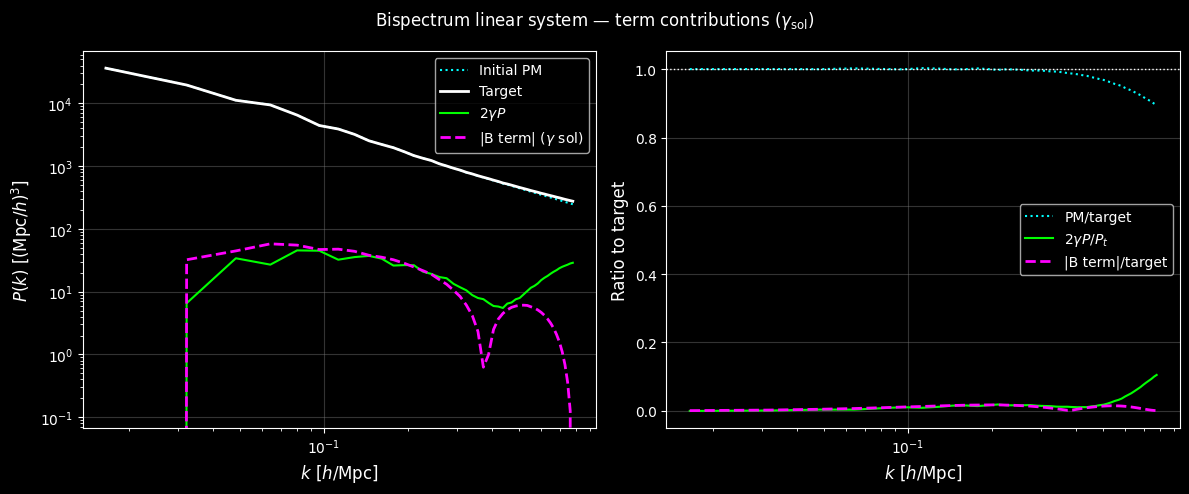

In [32]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k, Pk_pm_k,         label="Initial PM",       color="cyan",    ls="dotted", lw=1.5)
ax1.plot(k, Pk_nb_k,         label="Target",            color="white",   lw=2)
ax1.plot(k, 2*gamma_sol*Pk_pm_k, label=r"$2\gamma P$", color="lime",    lw=1.5)
ax1.plot(k, np.abs(B_term_sol),  label=r"|B term| ($\gamma$ sol)", color="magenta", ls="--", lw=2)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=12)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

ax2.plot(k, Pk_pm_k/Pk_nb_k,             color="cyan",    ls="dotted", lw=1.5, label="PM/target")
ax2.plot(k, 2*gamma_sol*Pk_pm_k/Pk_nb_k, color="lime",    lw=1.5, label=r"$2\gamma P/P_t$")
ax2.plot(k, np.abs(B_term_sol)/Pk_nb_k,  color="magenta", ls="--", lw=2, label="|B term|/target")
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=12)
ax2.set_ylabel("Ratio to target", fontsize=12)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)

plt.suptitle(r"Bispectrum linear system — term contributions ($\gamma_\mathrm{sol}$)")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Bk_linear_terms.pdf"), bbox_inches="tight")


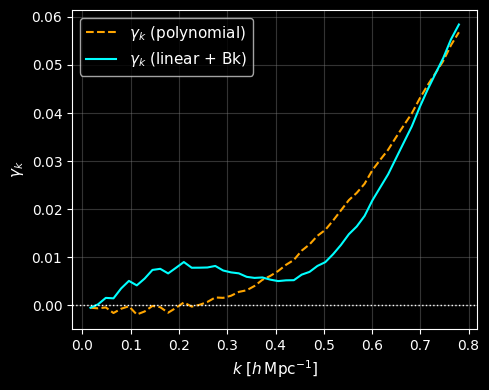

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(k, gamma_k,    label=r"$\gamma_k$ (polynomial)", color="orange", ls="--")
ax.plot(k, gamma_sol,  label=r"$\gamma_k$ (linear + Bk)", color="cyan")
ax.axhline(0, color="white", lw=1, ls=":")
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=11)
ax.set_ylabel(r"$\gamma_k$", fontsize=11)
ax.legend(fontsize=11); ax.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gammak_comparison.pdf"), bbox_inches="tight")


## 2-6) Displace particles with bispectrum-corrected $\gamma_k$

Same `get_phi_and_accel_corr` as section 2-2, now with `gamma_sol` in place of `gamma_k`.
The `delta_k_shift` is reused (not recomputed) since the PM density field hasn't changed.


In [34]:
phi_k_lin, accel_lin, _ = get_phi_and_accel_corr(
    gamma_sol, k, delta_k_shift, grid, BoxSize, n_threads=n_threads,
    zero_above_kmax=True, verbose=True)

pos_corr_lin = np.empty(pos_pm.shape, dtype="float32")
pos_corr_lin, *_ = displace_positions_interp(
    pos_pm.astype("float32"), pos_corr_lin,
    accel_lin[0].astype("float32"),
    accel_lin[1].astype("float32"),
    accel_lin[2].astype("float32"),
    length_grid, length_grid, length_grid, BoxSize, threshold=None, lr = 0.5) # previously threshold = BoxSize/grid

mean_disp_lin = np.mean(np.linalg.norm(pos_corr_lin - pos_pm.astype('float32'), axis=1))
print("Mean |disp| = %.4g Mpc/h  (cell = %.4g Mpc/h)" % (mean_disp_lin, BoxSize/grid))


  fill_fourier_grid: zero_above_kmax=True -> 8766155/16777216 points (52.3%) beyond k_max=0.7799 h/Mpc zeroed.
Mean |disp| = 0.08201 Mpc/h  (cell = 3.906 Mpc/h)


In [35]:
k_lin,   Pk_lin   = cached_measure_power('corr_lin_%s'%suffix,  pos_corr_lin,  BoxSize, grid, kedges, ells=ells, recompute = True)
#k_linr,  Pk_linr  = cached_measure_power('corr_linr_%s'%suffix, pos_corr_lin,  BoxSize, grid, kedges, ells=ells, remove_shotnoise=False)
#k_polyr, Pk_polyr = cached_measure_power('corr_polyr_%s'%suffix,pos_corr_poly, BoxSize, grid, kedges, ells=ells, remove_shotnoise=False)


  measured P(k) for 'corr_lin_fastpm_50_bins_256_grid' in 42.23s


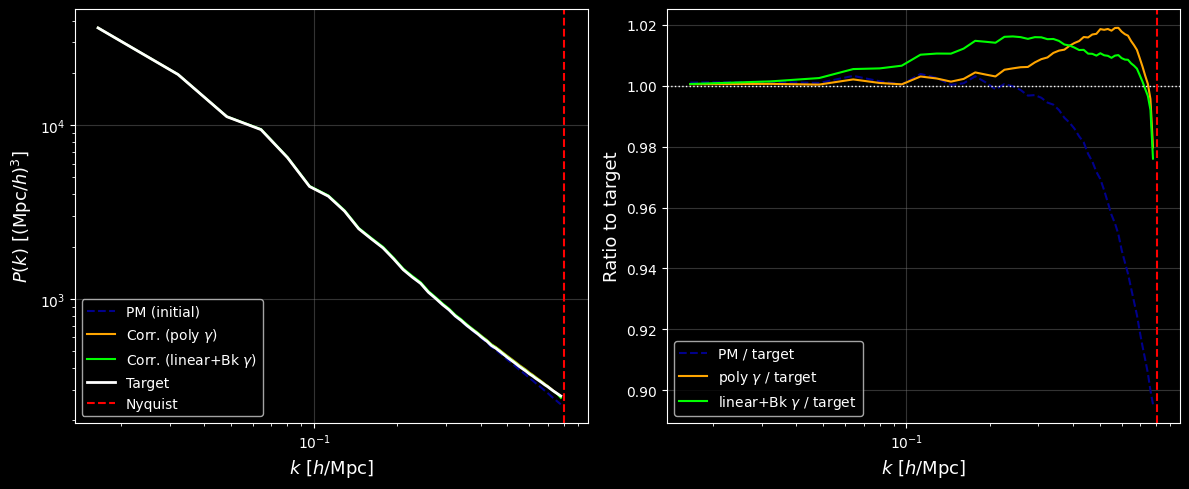

In [36]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k_pm,  Pk_pm,  label="PM (initial)",         color="darkblue", ls="--")
ax1.plot(k_poly,Pk_poly,label=r"Corr. (poly $\gamma$)",color="orange")
ax1.plot(k_lin, Pk_lin, label=r"Corr. (linear+Bk $\gamma$)", color="lime")
ax1.plot(k_nb,  Pk_nb,  label="Target",                color="white", lw=2)
ax1.axvline(kNyquist, color='r', ls='--', label='Nyquist')
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

for kk, Pk, lbl, col in [
    (k_pm,   Pk_pm,   "PM / target",       "darkblue"),
    (k_poly, Pk_poly, r"poly $\gamma$ / target", "orange"),
    (k_lin,  Pk_lin,  r"linear+Bk $\gamma$ / target", "lime"),
]:
    ax2.plot(kk, Pk/np.interp(kk, k_nb, Pk_nb), label=lbl, color=col,
              ls="--" if col=="darkblue" else "-")
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.axvline(kNyquist, color='r', ls='--')
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax2.set_ylabel("Ratio to target", fontsize=13)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Pk_corr_all.pdf"), bbox_inches="tight")


## 2-7) Cross-correlation coefficient $r(k)$

For the correlated case, improvements in $r(k)$ are the primary diagnostic — the whole
point of $\phi\propto\Delta$ is that the correction is coherent with the density field.

`remove_shotnoise=False` for both auto-spectra entering the denominator (same reason as the
Q-case notebook: pypower never subtracts shot noise from cross-spectra, so pairing a
shot-noise-subtracted auto with the raw cross term can give $r(k)>1$).


In [ ]:
def measure_crosscorr(pos_corr, pos_ref, k_ref_raw, Pk_ref_raw, BoxSize, grid, kedges, label=""):
    result_X = CatalogFFTPower(data_positions1=pos_ref, data_positions2=pos_corr,
                                boxsize=BoxSize, nmesh=grid, resampler=MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,
                                position_type='pos', dtype='f4')
    k_X, Pk_X = result_X.poles(ell=ells[0], return_k=True, complex=False)
    mask = ~np.isnan(k_X) & ~np.isnan(Pk_X)
    k_X, Pk_X = k_X[mask], Pk_X[mask]

    k_auto, Pk_auto = measure_power_pypower(pos_corr, BoxSize, grid, kedges,
                                             ells=ells, remove_shotnoise=False)
    Pk_ref_i  = np.interp(k_X, k_ref_raw, Pk_ref_raw)
    Pk_auto_i = np.interp(k_X, k_auto, Pk_auto)
    r = Pk_X / np.sqrt(Pk_ref_i * Pk_auto_i)
    return k_X, r


In [ ]:
k_rX_pm,   r_pm   = measure_crosscorr(pos_pm,       pos_nb, k_nb_raw, Pk_nb_raw, BoxSize, grid, kedges)
k_rX_poly, r_poly = measure_crosscorr(pos_corr_poly, pos_nb, k_nb_raw, Pk_nb_raw, BoxSize, grid, kedges)
k_rX_lin,  r_lin  = measure_crosscorr(pos_corr_lin,  pos_nb, k_nb_raw, Pk_nb_raw, BoxSize, grid, kedges)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(k_rX_pm,   r_pm,   '--', color="darkblue", lw=2, label="PM (initial)")
ax.plot(k_rX_poly, r_poly, '-',  color="orange",   lw=2, label=r"Corr. (poly $\gamma$)")
ax.plot(k_rX_lin,  r_lin,  '-',  color="lime",     lw=2, label=r"Corr. (linear+Bk $\gamma$)")
ax.axhline(1.0, color="white", lw=1, ls=":")
ax.axvline(kNyquist, color='r', ls='--')
ax.set_xscale("log")
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
ax.set_ylabel(r"$r(k) \equiv P_\times / \sqrt{P\,P^\mathrm{ref}}$", fontsize=12)
ax.legend(fontsize=10); ax.grid(color="gray", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "crosscorr_corr_all.pdf"), bbox_inches="tight")


## 2-8) Iterative solver linear in Bk

In [37]:
def correct_particles_corr(positions, BoxSize, grid, k_ref, Pk_ref, M,
                             measure_power_func, threshold=None, lr=1.0, n_threads=None,
                             zero_above_kmax=True, remeasure=True, verbose=True,
                             use_gamma_sq=False, krylov_opts=None,
                             k_before=None, Pk_before=None):
    '''
    Single-iteration correlated correction.

    Linear+Bk (use_gamma_sq=False, default):
        (2*diag(P) + M) @ gamma = P_target - P

    Nonlinear+Bk (use_gamma_sq=True):
        P + gamma^2*P + 2*gamma*P + M@gamma = P_target
        solved via scipy Krylov, initialised from the linear solution.

    M       : precomputed symmetrized bispectrum matrix (build_bispectrum_matrix).
    k_before, Pk_before : optional pre-measured P(k) of `positions`, same intent
                          as in correct_particles_with_Q (avoids a redundant pypower
                          call when called from iterate_correction_corr).
    '''
 

    if n_threads is None:
        n_threads = detect_compute_resources()['cpu_count'] or 1

    # -- P(k) of current positions --
    if k_before is None or Pk_before is None:
        k_before, Pk_before = measure_power_func(positions, BoxSize, grid)
    elif verbose:
        print("  reusing previously-measured P(k) (skipping pypower call)")

    Pk_ref_i = np.interp(k_before, k_ref, Pk_ref)

    # -- solve for gamma --
    A = 2 * np.diag(Pk_before) + M   # used as init for both paths
    gamma_lin = np.linalg.solve(A, Pk_ref_i - Pk_before)

    if not use_gamma_sq:
        gamma_sol = gamma_lin
    else:
        def residual(gamma):
            return (Pk_before + gamma**2 * Pk_before
                    + 2 * gamma * Pk_before + M @ gamma - Pk_ref_i)

        opts = {}
        if krylov_opts:
            opts.update(krylov_opts)
        solution = scipy.optimize.root(residual, x0=gamma_lin,
                                        method='krylov', options=opts)
        gamma_sol = solution['x']
        if verbose:
            max_res = np.max(np.abs(residual(gamma_sol)))
            print(f"  Krylov: converged={solution.success}  "
                  f"max_residual={max_res:.2e}  "
                  f"max|dgamma|={np.max(np.abs(gamma_sol - gamma_lin)):.4f}")

    # -- delta_k from current positions (CatalogMesh, no Pylians) --
    mesh = CatalogMesh(data_positions=positions, nmesh=grid, boxsize=BoxSize,
                        boxcenter=BoxSize/2., resampler='cic', interlacing=0,
                        position_type='pos', dtype='f4')
    delta_real = mesh.to_mesh(field='normalized_data', compensate=False)
    delta_pm_iter = np.array(delta_real[...], dtype='float32') - 1.0
    delta_k_shift = get_delta_fourier(delta_pm_iter, grid, BoxSize,
                                       n_threads=n_threads, apply_mas_deconv=True)

    # -- phi and gradients --
    phi_k, accel, n_zeroed = get_phi_and_accel_corr(
        gamma_sol, k_before, delta_k_shift, grid, BoxSize,
        n_threads=n_threads, zero_above_kmax=zero_above_kmax, verbose=verbose)

    # -- displace --
    cell = BoxSize / grid
    length_grid = np.arange(0., BoxSize, cell)
    pos_corrected = np.empty(positions.shape, dtype='float32')
    pos_corrected, *_ = displace_positions_interp(
        positions.astype('float32'), pos_corrected,
        accel[0].astype('float32'), accel[1].astype('float32'),
        accel[2].astype('float32'),
        length_grid, length_grid, length_grid, BoxSize, threshold=threshold, lr = lr) # cell before for threshold

    out = dict(positions_corrected=pos_corrected, gamma=gamma_sol,
               gamma_lin=gamma_lin, k=k_before, Pk_before=Pk_before,
               M=M, n_zeroed_above_kmax=n_zeroed)
    if use_gamma_sq:
        out['krylov_success'] = solution.success

    if remeasure:
        k_after, Pk_after = measure_power_func(pos_corrected, BoxSize, grid)
        out['k_after'], out['Pk_after'] = k_after, Pk_after

    return out


def iterate_correction_corr(positions, BoxSize, grid, k_ref, Pk_ref, M,
                              measure_power_func, n_iterations=2, threshold=None, lr=1.0,
                              use_gamma_sq=False, krylov_opts=None,
                              n_threads=None, zero_above_kmax=True,
                              recompute_bispectrum=False, bspec=None,
                              verbose=True):
    '''
    Iterative correlated correction, analogous to iterate_correction_with_Q.

    At each iteration:
      - delta_k is always recomputed from the current (displaced) positions.
      - P(k) from iteration i's output feeds directly into iteration i+1
        (no redundant pypower call).
      - M is kept fixed by default (recompute_bispectrum=False). Set
        recompute_bispectrum=True and pass the PolyBin3D bspec object to
        rebuild M from the updated density field at each step (expensive).

    use_gamma_sq : if True, passes through to correct_particles_corr to use
                   the Krylov nonlinear solve instead of the linear system.
    '''
    history = []
    current_positions = positions
    current_M = M
    k_before, Pk_before = None, None   # None on it=0 -> forces one real P(k) measurement

    for it in range(n_iterations):
        if verbose:
            print(f"=== iteration {it + 1}/{n_iterations} ===")

        # Optionally rebuild M from updated positions (expensive)
        if recompute_bispectrum and it > 0:
            if bspec is None:
                raise ValueError("pass bspec= when recompute_bispectrum=True")
            if verbose:
                print("  recomputing bispectrum matrix from current positions...")
            mesh = CatalogMesh(data_positions=current_positions, nmesh=grid,
                                boxsize=BoxSize, boxcenter=BoxSize/2.,
                                resampler='cic', interlacing=0,
                                position_type='pos', dtype='f4')
            delta_real = mesh.to_mesh(field='normalized_data', compensate=False)
            delta_new = np.array(delta_real[...], dtype='float32') - 1.0
            result_bk = bspec.Bk_ideal(delta_new, discreteness_correction=False)
            current_M = build_bispectrum_matrix(k_before, bspec.get_ks(),
                                                 result_bk['b0'])

        result = correct_particles_corr(
            current_positions, BoxSize, grid, k_ref, Pk_ref, current_M,
            measure_power_func, n_threads=n_threads,threshold = threshold,lr=lr, 
            zero_above_kmax=zero_above_kmax, remeasure=True, verbose=verbose,
            use_gamma_sq=use_gamma_sq, krylov_opts=krylov_opts,
            k_before=k_before, Pk_before=Pk_before)

        history.append(result)
        current_positions = result['positions_corrected']
        k_before = result['k_after']
        Pk_before = result['Pk_after']

        if verbose:
            Pk_ref_i = np.interp(k_before, k_ref, Pk_ref)
            rel = np.mean(np.abs((Pk_before - Pk_ref_i) / Pk_ref_i))
            print(f"  mean relative |P - P_target|/P_target: {rel:.4f}")

    return dict(positions=current_positions, history=history)

In [38]:
measure_power_func = lambda pos, B, g: measure_power_pypower(pos, B, g, kedges, ells=ells)

# Linear+Bk, 2 iterations (default)
loop_result = iterate_correction_corr(
    pos_pm, BoxSize, grid, k_nb, Pk_nb, M, measure_power_func,
    n_iterations=3, use_gamma_sq=False, n_threads=resources['cpu_count'],
    verbose=True, threshold = None)

=== iteration 1/3 ===
  fill_fourier_grid: zero_above_kmax=True -> 8766155/16777216 points (52.3%) beyond k_max=0.7799 h/Mpc zeroed.
  mean relative |P - P_target|/P_target: 0.0335
=== iteration 2/3 ===
  reusing previously-measured P(k) (skipping pypower call)
  fill_fourier_grid: zero_above_kmax=True -> 8766155/16777216 points (52.3%) beyond k_max=0.7799 h/Mpc zeroed.
  mean relative |P - P_target|/P_target: 0.0086
=== iteration 3/3 ===
  reusing previously-measured P(k) (skipping pypower call)
  fill_fourier_grid: zero_above_kmax=True -> 8766155/16777216 points (52.3%) beyond k_max=0.7799 h/Mpc zeroed.
  mean relative |P - P_target|/P_target: 0.0032


In [39]:
def plot_iteration_history(history, k_pm, Pk_pm, k_target, Pk_target,
                             kNyquist=None, figroot=None, cmap=cm.viridis):
    '''
    Two-column diagnostic plot (P(k), and P(k)/P_target ratio) showing the
    initial PM spectrum, the target, and every iteration's corrected spectrum
    from iterate_correction_with_Q's `history` list.

    Parameters
    ----------
    history : list of dicts, as returned in loop_result['history'] from
        iterate_correction_with_Q -- each needs 'k_after' and 'Pk_after'
    k_pm, Pk_pm : the *initial*, uncorrected PM power spectrum (pre-loop)
    k_target, Pk_target : the reference/target power spectrum
    kNyquist : optional, draws a vertical reference line on both panels
    figroot : optional directory to save the figure pdf into
    cmap : colormap used to shade iterations from early (light) to late (dark)
    '''
    n_it = len(history)
    colors = cmap(np.linspace(0.25, 0.95, n_it))

    fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
    ax1, ax2 = axes

    # --- left: P(k) ---
    ax1.plot(k_pm, Pk_pm, label="PM (initial)", color="darkblue", ls="--")
    for i, h in enumerate(history):
        ax1.plot(h['k_after'], h['Pk_after'], color=colors[i],
                  label=f"corrected, it. {i + 1}/{n_it}")
    ax1.plot(k_target, Pk_target, label="target", color="white", lw=2)
    if kNyquist is not None:
        ax1.axvline(kNyquist, color='r', ls='--', label='Nyquist freq = %.2f' % kNyquist)
    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
    ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
    ax1.legend(fontsize=9); ax1.grid(color="grey", alpha=0.4)

    # --- right: ratio to target ---
    Pk_target_on_pm = np.interp(k_pm, k_target, Pk_target)
    ax2.plot(k_pm, Pk_pm / Pk_target_on_pm, label="PM (initial) / target",
              color="darkblue", ls="--")
    for i, h in enumerate(history):
        Pk_target_i = np.interp(h['k_after'], k_target, Pk_target)
        ax2.plot(h['k_after'], h['Pk_after'] / Pk_target_i, color=colors[i],
                  label=f"corrected, it. {i + 1}/{n_it} / target")
    ax2.axhline(1.0, color="white", lw=1, ls=":")
    if kNyquist is not None:
        ax2.axvline(kNyquist, color='r', ls='--')
    ax2.set_xscale("log")
    ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
    ax2.set_ylabel(r"$P(k)$ ratio", fontsize=13)
    ax2.legend(fontsize=9); ax2.grid(color="grey", alpha=0.4)

    plt.tight_layout()
    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, "Pk_results_correlated_iterations.pdf"), bbox_inches="tight")
    return fig, axes

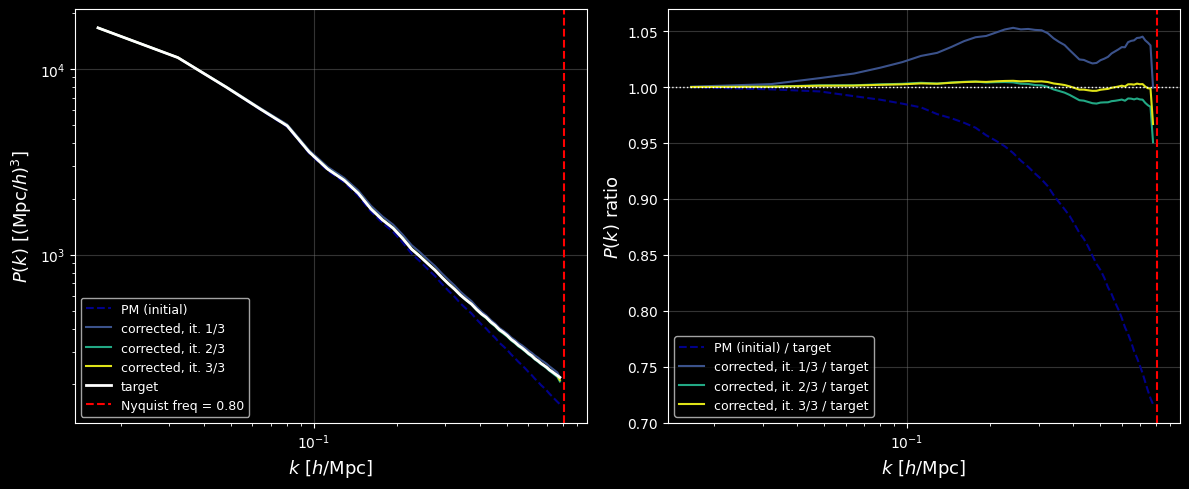

In [40]:
fig, axes = plot_iteration_history(
    loop_result['history'], k_pm, Pk_pm, k_nb, Pk_nb,
    kNyquist=kNyquist, figroot=figroot,
)

## 2-9) Root finding 

In [41]:
# Nonlinear (gamma^2 + Bk), single shot
loop_result_nl = iterate_correction_corr(
    pos_pm, BoxSize, grid, k_nb, Pk_nb, M, measure_power_func,
    n_iterations=2, use_gamma_sq=True, verbose=True)

pos_corrected_corr = loop_result['positions']

=== iteration 1/2 ===
  Krylov: converged=True  max_residual=2.48e-06  max|dgamma|=0.0164
  fill_fourier_grid: zero_above_kmax=True -> 8766155/16777216 points (52.3%) beyond k_max=0.7799 h/Mpc zeroed.
  mean relative |P - P_target|/P_target: 0.0263
=== iteration 2/2 ===
  reusing previously-measured P(k) (skipping pypower call)
  Krylov: converged=True  max_residual=6.72e-10  max|dgamma|=0.0006
  fill_fourier_grid: zero_above_kmax=True -> 8766155/16777216 points (52.3%) beyond k_max=0.7799 h/Mpc zeroed.
  mean relative |P - P_target|/P_target: 0.0087


In [42]:
k_root,   Pk_root   = cached_measure_power('corr_root_%s'%suffix,  pos_corrected_corr,  BoxSize, grid, kedges, ells=ells, recompute = True)

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes

ax1.plot(k_pm,  Pk_pm,  label="PM (initial)",         color="darkblue", ls="--")
ax1.plot(k_poly,Pk_poly,label=r"Corr. (poly $\gamma$)",color="orange")
ax1.plot(k_root,Pk_root,label=r"Corr. (poly $\gamma$ 2nd o.)",color="yellow")
ax1.plot(k_lin, Pk_lin, label=r"Corr. (linear+Bk $\gamma$)", color="lime")
ax1.plot(k_nb,  Pk_nb,  label="Target",                color="white", lw=2)
ax1.axvline(kNyquist, color='r', ls='--', label='Nyquist')
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
ax1.legend(fontsize=10); ax1.grid(color="grey", alpha=0.4)

for kk, Pk, lbl, col in [
    (k_pm,   Pk_pm,   "PM / target",       "darkblue"),
    (k_poly, Pk_poly, r"poly $\gamma$ / target", "orange"),
    (k_lin,  Pk_lin,  r"linear+Bk $\gamma$ / target", "lime"),
    (k_root,  Pk_root,  r" (poly $\gamma$ 2nd o / target", "yellow"),
]:
    ax2.plot(kk, Pk/np.interp(kk, k_nb, Pk_nb), label=lbl, color=col,
              ls="--" if col=="darkblue" else "-")
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.axvline(kNyquist, color='r', ls='--')
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax2.set_ylabel("Ratio to target", fontsize=13)
ax2.legend(fontsize=10); ax2.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Pk_corr_all.pdf"), bbox_inches="tight")

# 3) Testing different lambda, iterative orrections 

In [38]:
def run_lambda_comparison(pos_pm, BoxSize, grid, k_nb, Pk_nb, M, measure_power_func,
                           lambdas=(0.3, 0.5, 0.8), n_iterations=3, n_threads=None):
    '''Runs the correlated correction once per lr value. Returns a dict with
    the initial (pm) P(k) and one iterate_correction_corr result per lr,
    kept separate from plotting so re-plotting doesn't require re-running
    the (expensive) correction.'''
    k_pm, Pk_pm = measure_power_func(pos_pm, BoxSize, grid)

    results = {"k_pm": k_pm, "Pk_pm": Pk_pm, "by_lr": {}}
    for lr in lambdas:
        print(f"=== lr = {lr} ===")
        loop_result = iterate_correction_corr(
            pos_pm, BoxSize, grid, k_nb, Pk_nb, M, measure_power_func,
            n_iterations=n_iterations, lr=lr, n_threads=n_threads, verbose=False)
        results["by_lr"][lr] = loop_result

    return results

def plot_lambda_comparison(results, k_nb, Pk_nb, figroot=None,
                            fname="corr_lambda_comparison.pdf"):
    lambdas = list(results["by_lr"].keys())
    k_pm, Pk_pm = results["k_pm"], results["Pk_pm"]

    fig, axes = plt.subplots(1, len(lambdas), figsize=(6*len(lambdas), 5),
                              sharey=True, constrained_layout=True)
    if len(lambdas) == 1:
        axes = [axes]

    cmap = cm.viridis
    Pk_nb_on_pm = np.interp(k_pm, k_nb, Pk_nb)

    for ax, lr in zip(axes, lambdas):
        loop_result = results["by_lr"][lr]
        n_iterations = len(loop_result["history"])
        colors = cmap(np.linspace(0.25, 0.95, n_iterations))

        ax.plot(k_pm, Pk_pm / Pk_nb_on_pm, color="darkblue", ls="--", label="stage 0 (PM)")
        for i, h in enumerate(loop_result["history"]):
            Pk_nb_i = np.interp(h["k_after"], k_nb, Pk_nb)
            ax.plot(h["k_after"], h["Pk_after"] / Pk_nb_i, color=colors[i], label=f"stage {i+1}")
        ax.axhline(1.0, color="white", lw=1, ls=":")
        ax.set_xscale("log")
        ax.set_title(r"$\mathrm{lr} = %.2f$" % lr, fontsize=14)
        ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(r"$P(k)/P_{\rm target}(k)$", fontsize=12)
    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, fname), bbox_inches="tight")
    return fig, axes

In [39]:
measure_power_func = lambda pos, B, g: measure_power_pypower(pos, B, g, kedges, ells=ells)

results = run_lambda_comparison(
    pos_pm, BoxSize, grid, k_nb, Pk_nb, M, measure_power_func,
    lambdas=(0.3, 0.5, 0.8), n_iterations=3, n_threads=resources['cpu_count'])

=== lr = 0.3 ===
=== lr = 0.5 ===
=== lr = 0.8 ===


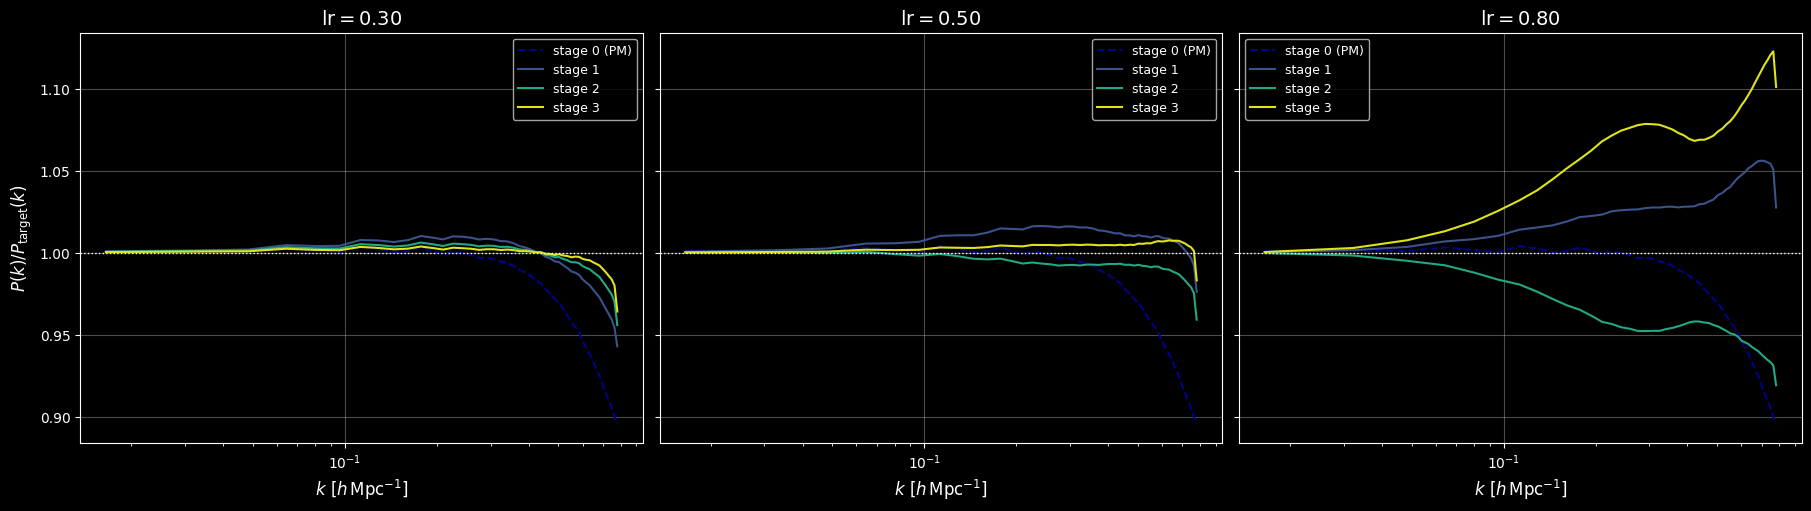

In [40]:
fig, axes = plot_lambda_comparison(results, k_nb, Pk_nb, figroot=figroot)



# Misc) Root-finding with full system

The full system including $\gamma_k^2$ is nonlinear and cannot be solved per-$k$
independently since the bispectrum term couples all $k$-bins:
$$P(k) + \gamma_k^2P(k) + 2\gamma_kP(k) + \text{B.Term}(k;\gamma) = P_\text{target}(k)$$
We use `scipy.optimize.root` (Krylov method) initialized from `gamma_sol`.

**Two bugs fixed from the original (see intro):**
1. `bispectrum_term` in cell 81 of the original used `2/BoxSize³` (old normalization);
   `correlated_full_system` below uses `1/(4π³)` (corrected).
2. Cell 87 of the original displaced with `weights1D = solution["x"]` missing the
   `/k²` division; `get_phi_and_accel_corr` takes $\gamma_k$ and divides by $k^2$
   internally, so this is no longer possible to get wrong.


In [ ]:
def correlated_full_system(gamma_vec, k_vec, Pk_target, Pk_pm, ks, bk_mono):
    '''
    Residual of P + gamma^2*P + 2*gamma*P + B.Term(gamma) - P_target = 0.
    Uses the corrected bispectrum normalization 1/(4*pi^3).
    '''
    _, B = compute_bispectrum_term(gamma_vec, k_vec, ks, bk_mono)
    B_interp = np.interp(k_vec, np.unique(ks[0, :]), B)
    return Pk_pm - Pk_target + gamma_vec**2*Pk_pm + 2*gamma_vec*Pk_pm + B_interp


In [ ]:
# Krylov root-finder; init from linear solution, short run for demonstration
solution = scipy.optimize.root(
    correlated_full_system, x0=gamma_sol,
    args=(k, Pk_nb_k, Pk_pm_k, ks, bk_uncorr),
    method="krylov",
    options={"maxiter": 10, "fatol": 1e-3})

print("Converged:", solution.success, " message:", solution.message)
gamma_krylov = solution["x"]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(k, gamma_k,      label=r"$\gamma_k$ (polynomial)",  color="orange", ls="--")
ax.plot(k, gamma_sol,    label=r"$\gamma_k$ (linear+Bk)",   color="cyan")
ax.plot(k, gamma_krylov, label=r"$\gamma_k$ (Krylov)",      color="magenta", ls=":")
ax.axhline(0, color="white", lw=1, ls=":")
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=11)
ax.set_ylabel(r"$\gamma_k$", fontsize=11)
ax.legend(fontsize=10); ax.grid(color="grey", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gammak_all_methods.pdf"), bbox_inches="tight")


In [ ]:
# Displace with Krylov gamma -- note the /k^2 is inside get_phi_and_accel_corr
phi_k_kry, accel_kry, _ = get_phi_and_accel_corr(
    gamma_krylov, k, delta_k_shift, grid, BoxSize, n_threads=n_threads,
    zero_above_kmax=True, verbose=True)

pos_corr_kry = np.empty(pos_pm.shape, dtype="float32")
pos_corr_kry, *_ = displace_positions_interp(
    pos_pm.astype("float32"), pos_corr_kry,
    accel_kry[0].astype("float32"),
    accel_kry[1].astype("float32"),
    accel_kry[2].astype("float32"),
    length_grid, length_grid, length_grid, BoxSize, threshold=BoxSize/grid)

k_kry, Pk_kry = cached_measure_power('corr_krylov', pos_corr_kry, BoxSize, grid, kedges, ells=ells, recompute=True)


# Appendix: synthetic mock validation


Self-contained sanity check of the core pipeline functions on a lognormal mock catalog.
No pypower, readgadget, or real snapshots needed. Re-uses `get_roots_gamma`,
`build_bispectrum_matrix`, `get_phi_and_accel_corr`, `displace_positions_interp`.


In [ ]:
def cic_density_mock(positions, BoxSize, grid):
    N = positions.shape[0]; cell = BoxSize/grid
    pos_cell = positions/cell; i0 = np.floor(pos_cell).astype(int)
    d = pos_cell - i0; rho = np.zeros((grid,grid,grid))
    for dx in (0,1):
        for dy in (0,1):
            for dz in (0,1):
                w = (d[:,0] if dx else 1-d[:,0])*(d[:,1] if dy else 1-d[:,1])*(d[:,2] if dz else 1-d[:,2])
                np.add.at(rho, ((i0[:,0]+dx)%grid,(i0[:,1]+dy)%grid,(i0[:,2]+dz)%grid), w)
    return rho/N*grid**3 - 1.0

def measure_pk_mock(positions, BoxSize, grid, kbins, subtract_shotnoise=True):
    delta = cic_density_mock(positions, BoxSize, grid)
    V = BoxSize**3; dV = (BoxSize/grid)**3
    delta_k = np.fft.fftn(delta)*dV/V; pf = (V*np.abs(delta_k)**2).ravel()
    kf = 2*np.pi/BoxSize; k1d = np.fft.fftfreq(grid,d=1./grid)*kf
    KX,KY,KZ = np.meshgrid(k1d,k1d,k1d,indexing='ij'); kmag = np.sqrt(KX**2+KY**2+KZ**2).ravel()
    idx = np.digitize(kmag, kbins)
    k_out,P_out = [],[]
    for b in range(1,len(kbins)):
        sel = idx==b
        if sel.sum()==0: continue
        k_out.append(kmag[sel].mean()); P_out.append(pf[sel].mean())
    k_out,P_out = np.array(k_out),np.array(P_out)
    if subtract_shotnoise: P_out -= V/positions.shape[0]
    return k_out, P_out

def lognormal_mock(Pk_func, BoxSize, grid, nbar, seed=None):
    rng = np.random.default_rng(seed); w = rng.standard_normal((grid,grid,grid))
    kf = 2*np.pi/BoxSize; k1d = np.fft.fftfreq(grid,d=1./grid)*kf
    KX,KY,KZ = np.meshgrid(k1d,k1d,k1d,indexing='ij'); kmag = np.sqrt(KX**2+KY**2+KZ**2)
    dV = (BoxSize/grid)**3; Pk = Pk_func(kmag.ravel()).reshape(kmag.shape); Pk[kmag==0]=0.
    delta_g = np.fft.ifftn(np.sqrt(np.clip(Pk,0,None)/dV)*np.fft.fftn(w)).real
    sigma2 = delta_g.var(); lam = np.clip(nbar*(np.exp(delta_g-sigma2/2.)-1.+1.)*dV,0,None)
    counts = rng.poisson(lam); idx = np.argwhere(counts>0)
    base = np.repeat(idx, counts[counts>0], axis=0).astype(float)
    return ((base + rng.uniform(0,1,base.shape))*(BoxSize/grid)) % BoxSize


In [ ]:
BoxSize_m, grid_m, nbar_m = 200.0, 32, 0.02
kbins_m = np.linspace(0.05, 0.9, 14)

def P_PM_m(k):  return 1.2e4*(k/0.15)**-1.6/(1+(k/0.15)**2)
def P_tgt_m(k): return 2.0e4*(k/0.18)**-1.5/(1+(k/0.18)**2)

pos_pm_m = lognormal_mock(P_PM_m, BoxSize_m, grid_m, nbar_m, seed=42)
pos_nb_m = lognormal_mock(P_tgt_m, BoxSize_m, grid_m, nbar_m, seed=42)  # same seed -> correlated

k_pm_m, Pk_pm_m = measure_pk_mock(pos_pm_m, BoxSize_m, grid_m, kbins_m)
k_nb_m, Pk_nb_m = measure_pk_mock(pos_nb_m, BoxSize_m, grid_m, kbins_m)

roots_m, coeffs_m = get_roots_gamma(k_pm_m, Pk_pm_m, Pk_nb_m)
gamma_k_m = roots_m[:, 1].real
print("gamma_k (mock):", gamma_k_m[:5])

# Reconstruct expected P(k) from polynomial
P_check = Pk_pm_m*(1 + gamma_k_m)**2
print("Max relative error in polynomial reconstruction:",
      np.max(np.abs(P_check - Pk_nb_m)/Pk_nb_m))

# Displace with polynomial gamma
delta_pm_m = cic_density_mock(pos_pm_m, BoxSize_m, grid_m)
delta_k_m  = get_delta_fourier(delta_pm_m, grid_m, BoxSize_m, n_threads=2)
phi_k_m, accel_m, n_z = get_phi_and_accel_corr(
    gamma_k_m, k_pm_m, delta_k_m, grid_m, BoxSize_m, n_threads=2,
    zero_above_kmax=True, verbose=True)

cell_m = BoxSize_m/grid_m; lg_m = np.arange(0., BoxSize_m, cell_m)
pos_corr_m = np.empty(pos_pm_m.shape, dtype="float32")
pos_corr_m, *_ = displace_positions_interp(
    pos_pm_m.astype("float32"), pos_corr_m,
    accel_m[0].astype("float32"), accel_m[1].astype("float32"), accel_m[2].astype("float32"),
    lg_m, lg_m, lg_m, BoxSize_m, threshold=BoxSize_m/grid_m)

k_corr_m, Pk_corr_m = measure_pk_mock(pos_corr_m, BoxSize_m, grid_m, kbins_m)
print("Mock validation done. positions_corrected dtype:", pos_corr_m.dtype)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(k_pm_m,   Pk_pm_m,   'o-', label="PM (initial)",  color="dodgerblue")
ax.plot(k_nb_m,   Pk_nb_m,   '-',  label="Target",        color="white", lw=2)
ax.plot(k_corr_m, Pk_corr_m, 's--',label="Corrected",     color="orange")
ax.set_xscale("log")
ax.set_xlabel(r"$k$"); ax.set_ylabel(r"$P(k)$")
ax.legend(fontsize=10); ax.grid(color="grey", alpha=0.4)
ax.set_title("Synthetic-mock validation: correlated case")
plt.tight_layout()
